Claudia Gallego y Paula Esteve | Gener 2025

# Reentrenamiento Avanzado: YOLO11 y Mask R-CNN

Este notebook implementa un proceso completo de reentrenamiento y experimentación con:
- **YOLO11** para detección de objetos
- **Mask R-CNN** para segmentación de instancias

Para empezar el proyecto, lo primero que hicimos fue preparar el entorno de trabajo e importar las librerias necesarias para ejecutar todo el notebook. Decidimos comparar dos enfoques distintos como se pedia en el enunciado, YOLO11 para la detección del implante y Mask R-CNN para su identificación. 

En esta celda, dejamos listo el entorno importando las librerías necesarias para cargar y procesar imágenes, entrenar los modelos, visualizar resultados y registrar las métricas de evaluación.

In [ ]:
import os
import zipfile
import time
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
from PIL import Image
import albumentations as A
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms
from torchvision.models.detection import faster_rcnn, mask_rcnn
from torchvision.ops import box_iou
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from pathlib import Path


In [2]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Dispositivo disponible: {device}")

Dispositivo disponible: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Memoria disponible: 8.59 GB


In [ ]:

SEED = 42
import random
random.seed(SEED)  
np.random.seed(SEED)  
torch.manual_seed(SEED)  

if device == "cuda":
    torch.cuda.manual_seed_all(SEED)  # PyTorch GPU

## 2. Carga y preparación del Dataset YOLO

En esta parte hemos preparado el dataset de implantes para poder entrenar y evaluar YOLO de forma correcta. El conjunto que nos dieron tiene 200 imágenes en total, y nos encontramos con dos casos: la gran mayoría sí tienen implante, pero también hay un pequeño grupo sin implante, que en nuestro caso son 4 imágenes (las 123, 125, 184 y 158). Aunque son pocas consideramos que són importantes porque nos permiten comprobar si el modelo genera falsos positivos cuando en realidad no hay nada que detectar.

Para entrenar YOLO usamos las anotaciones en formato de bounding boxes, que ya habíamos generado en el ejercico anterior.

Luego dividimos el conjunto de imagenes en 70% train, 15% val y 15% Test. Con las 4 imagenes sin implante hemos decidido ponerlas solo en test. La idea es que el test sea el sitio donde medimos si el modelo ha aprendido también a no detectar nada cuando no toca. Si las pusiéramos en entrenamiento, el modelo podría aprender de estos ejemplos negativos y luego el test perdería parte de su sentido, porque ya no estaríamos midiendo esa capacidad en datos no vistos. Por eso, nuestro test final queda con 30 imágenes con implante + 4 sin implante.

In [4]:
# Rutas del dataset
IMAGES_DIR = 'C:\\Users\\Paess\\Documents\\Uni\\VO\\PFinal\\Implantes'
MASKS_DIR = 'C:\\Users\\Paess\\Documents\\Uni\\VO\\PFinal\\Resultados'
BBOX_DIR = 'C:\\Users\\Paess\\Documents\\Uni\\VO\\PFinal\\bbounding_box'
ANNOTATIONS_FILE = 'C:\\Users\\Paess\\Documents\\Uni\\VO\\PFinal\\bbounding_box\\bounding_boxes_yolo.txt'

In [ ]:
annotations_dict = {}

with open(ANNOTATIONS_FILE, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 5:
            img_id = parts[0]
            bbox = ' '.join(parts[1:])
            
            if img_id not in annotations_dict:
                annotations_dict[img_id] = []
            annotations_dict[img_id].append(bbox)

imgs = sorted([f for f in os.listdir(IMAGES_DIR) if f.endswith(('.jpg', '.png', '.jpeg'))])
total = len(imgs)

images_without_implant = ['123.jpg', '125.jpg', '184.jpg', '158.jpg']

imgs_with_implant = [img for img in imgs if img not in images_without_implant]
imgs_without_implant = [img for img in imgs if img in images_without_implant]

random.shuffle(imgs_with_implant)

train_end = int(0.7 * len(imgs_with_implant))
val_end = int(0.85 * len(imgs_with_implant))

splits = {
    'train': imgs_with_implant[:train_end],  
    'val': imgs_with_implant[train_end:val_end],  
    'test': imgs_with_implant[val_end:] + imgs_without_implant  
}

print(f"\nDivisión del dataset:")
print(f"  Train: {len(splits['train'])} imágenes")
print(f"  Val: {len(splits['val'])} imágenes")
print(f"  Test: {len(splits['test'])} imágenes")

Anotaciones cargadas para 196 IDs de imágenes
Ejemplo de anotaciones para la imagen ID '100': ['0 0.470313 0.463281 0.689063 0.925000']

División del dataset:
  Train: 137 imágenes (solo con implante)
  Val: 29 imágenes (solo con implante)
  Test: 34 imágenes (30 con implante + 4 sin implante)

Imágenes sin implante en test: ['123.jpg', '125.jpg', '158.jpg', '184.jpg']


In [6]:
YOLO_OUTPUT_DIR = 'C:\\Users\\Paess\\Documents\\Uni\\VO\\PFinal\\Yolo_output'
for split in ['train', 'val', 'test']:
    os.makedirs(f"{YOLO_OUTPUT_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_OUTPUT_DIR}/labels/{split}", exist_ok=True)

✓ Estructura de directorios creada en 'C:\Users\Paess\Documents\Uni\VO\PFinal\Yolo_output'


In [7]:
for split_name, split_imgs in splits.items():
    for img_name in split_imgs:
        img_src = os.path.join(IMAGES_DIR, img_name)
        img_dst = f"{YOLO_OUTPUT_DIR}/images/{split_name}/{img_name}"
        shutil.copy(img_src, img_dst)
        
        img_id = img_name.rsplit('.', 1)[0]
        label_name = img_id + '.txt'
        label_path = f"{YOLO_OUTPUT_DIR}/labels/{split_name}/{label_name}"
        
        if img_id in annotations_dict:
            with open(label_path, 'w') as f:
                for bbox in annotations_dict[img_id]:
                    f.write(bbox + '\n')
        else:
            with open(label_path, 'w') as f:
                pass

In [8]:
yaml_content = f"""path: {os.path.abspath(YOLO_OUTPUT_DIR)}
train: images/train
val: images/val
test: images/test

nc: 1
names: ['implant']
"""

yaml_path = f"{YOLO_OUTPUT_DIR}/dataset.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content)

YOLO_YAML = 'C:\\Users\\Paess\\Documents\\Uni\\VO\\PFinal\\Yolo_output\\dataset.yaml'

## 3. Experimentos con YOLO11 

En este apartado hemos reentrenado varios modelos de YOLO11 con distintos hiperparámetros. Lo que hemos hecho es plantear un pequeño gridsearch con los hiperparámetros que nos parecian más interesantes. 

Una de las cosas más importantes que quisimos justificar fue el freeze. Probamos freeze = 0 (entrenar todo el modelo) frente a freeze = 10 (congelar capas iniciales y ajustar sobre todo las finales) porque estamos usando un modelo preentrenado y queríamos ver qué nos convenía más: si “reaprender” todas las características desde cero para adaptarnos al dominio de radiografías, o aprovechar que las capas iniciales ya detectan patrones generales y solo ajustar la parte final para evitar overfitting. 

También probamos dos valores de learning rate inicial (0.01 y 0.005) porque es el parámetro que más rápido se nota si el entrenamiento es estable o no.

Decidimos fijar el batch =4 por limitaciones de memoria y pudimos comprobar después de varias pruebas que era el que mejor funcionaba en este caso. 

Finalmente, probamos los modelos con augment = True/False. Queríamos comprobar si el aplicar transformaciones ayudaba al modelo a generalizar mejor. 

In [12]:
from itertools import product

param_grid = {
    'model': ['yolo11n.pt'],
    'freeze': [0, 10],
    'epochs': [50],
    'lr0': [0.01, 0.005],
    'batch': [4],
    'augment': [False, True],
    'patience': [10]
}

param_names = list(param_grid.keys())
all_combinations = [
    dict(zip(param_names, values))
    for values in product(*param_grid.values())
]

print(f"Total combinaciones: {len(all_combinations)}")
for idx, config in enumerate(all_combinations):
    print(f"Exp {idx:02d}: {config}")

Total combinaciones: 8
Exp 00: {'model': 'yolo11n.pt', 'freeze': 0, 'epochs': 50, 'lr0': 0.01, 'batch': 4, 'augment': False, 'patience': 10}
Exp 01: {'model': 'yolo11n.pt', 'freeze': 0, 'epochs': 50, 'lr0': 0.01, 'batch': 4, 'augment': True, 'patience': 10}
Exp 02: {'model': 'yolo11n.pt', 'freeze': 0, 'epochs': 50, 'lr0': 0.005, 'batch': 4, 'augment': False, 'patience': 10}
Exp 03: {'model': 'yolo11n.pt', 'freeze': 0, 'epochs': 50, 'lr0': 0.005, 'batch': 4, 'augment': True, 'patience': 10}
Exp 04: {'model': 'yolo11n.pt', 'freeze': 10, 'epochs': 50, 'lr0': 0.01, 'batch': 4, 'augment': False, 'patience': 10}
Exp 05: {'model': 'yolo11n.pt', 'freeze': 10, 'epochs': 50, 'lr0': 0.01, 'batch': 4, 'augment': True, 'patience': 10}
Exp 06: {'model': 'yolo11n.pt', 'freeze': 10, 'epochs': 50, 'lr0': 0.005, 'batch': 4, 'augment': False, 'patience': 10}
Exp 07: {'model': 'yolo11n.pt', 'freeze': 10, 'epochs': 50, 'lr0': 0.005, 'batch': 4, 'augment': True, 'patience': 10}


### 3.1. Ejecución del Grid Search

In [13]:
yolo_results = {}

for idx, config in enumerate(all_combinations):
    exp_name = f"exp_{idx:02d}"
    print(f"\n{'='*70}")
    print(f"Experimento: {exp_name.upper()}")
    print(f"Configuración: {config}")
    print(f"{'='*70}")
    
    model = YOLO(config['model'])
    
    start_time = time.time()
    
    results = model.train(
        data=YOLO_YAML,
        epochs=config['epochs'],
        imgsz=640,
        batch=config['batch'],
        lr0=config['lr0'],
        freeze=config['freeze'],
        patience=config['patience'],
        workers=0,
        augment=config['augment'],
        project="runs/yolo_grid_search/",
        name=exp_name,
        exist_ok=True,
        save=False,
        plots=False,
        verbose=False
    )
    
    training_time = time.time() - start_time
    
    metrics = model.val(data=YOLO_YAML, verbose=False)
    
    yolo_results[exp_name] = {
        'config': config,
        'model': model,
        'training_time': training_time,
        'map50': float(metrics.box.map50),
        'map': float(metrics.box.map),
        'precision': float(metrics.box.mp),
        'recall': float(metrics.box.mr)
    }
    
    print(f"\n{exp_name} completado:")
    print(f"  Tiempo: {training_time:.1f}s")
    print(f"  mAP@50: {metrics.box.map50:.4f}")
    print(f"  mAP@50-95: {metrics.box.map:.4f}")
    print(f"  Precision: {metrics.box.mp:.4f}")
    print(f"  Recall: {metrics.box.mr:.4f}")

print(f"\n{'='*70}")
print("GRID SEARCH COMPLETADO")
print(f"{'='*70}")


Experimento: EXP_00
Configuración: {'model': 'yolo11n.pt', 'freeze': 0, 'epochs': 50, 'lr0': 0.01, 'batch': 4, 'augment': False, 'patience': 10}
New https://pypi.org/project/ultralytics/8.3.248 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.237  Python-3.13.9 torch-2.11.0.dev20251214+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Paess\Documents\Uni\VO\PFinal\Yolo_output\dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras

### 3.2. Análisis y Comparación de Resultados
Al mirar la tabla del grid search nos quedó bastante claro que los experimentos se separan en dos grupos. Los que tienen freeze = 10 (exp_04 a exp_07) salen claramente mejor en métricas: el mAP@50 se queda en 0.9942 y el mAP@50-95 en 0.8949. En cambio, cuando entrenamos todo el modelo (freeze = 0, exp_00 a exp_03), baja un poco el rendimiento, con mAP@50 = 0.9821 y mAP@50-95 = 0.8217.

Otra cosa que nos llamó la atención es que dentro del bloque de freeze=10, cambiar el learning rate entre 0.01 y 0.005 o activar/desactivar augmentation prácticamente no cambia nada, ya que las métricas son practicamente iguales. 

Por estos motivos seleccionamos exp_04 como el mejor modelo; aunque varias configuraciones empatan en métricas, elegimos la opción más simple (sin augmentación) al no aportar mejoras adicionales.


In [ ]:
results_data = []

for exp_name, result in yolo_results.items():
    results_data.append({
        'Experimento': exp_name,
        'Modelo': result['config']['model'],
        'Freeze': result['config']['freeze'],
        'LR': result['config']['lr0'],
        'Batch': result['config']['batch'],
        'Augment': 'Sí' if result['config']['augment'] else 'No',
        'Épocas': result['config']['epochs'],
        'mAP@50': result['map50'],
        'mAP@50-95': result['map'],
        'Precision': result['precision'],
        'Recall': result['recall'],
        'Tiempo (min)': result['training_time'] / 60
    })

df_results = pd.DataFrame(results_data)
df_results = df_results.sort_values('mAP@50', ascending=False)

print("\n" + "="*100)
print("RESULTADOS DEL GRID SEARCH - YOLO11")
print("="*100)
print(df_results.to_string(index=False))
print("\n")

best_exp = df_results.iloc[0]['Experimento']
best_map50 = df_results.iloc[0]['mAP@50']

print(f"MEJOR MODELO: {best_exp}")
print(f"mAP@50: {best_map50:.4f}")
print(f"Configuración: {yolo_results[best_exp]['config']}")


RESULTADOS DEL GRID SEARCH - YOLO11
Experimento     Modelo  Freeze    LR  Batch Augment  Épocas   mAP@50  mAP@50-95  Precision   Recall  Tiempo (min)
     exp_04 yolo11n.pt      10 0.010      4      No      50 0.994231   0.894910   1.000000 0.972614      6.102516
     exp_05 yolo11n.pt      10 0.010      4      Sí      50 0.994231   0.894910   1.000000 0.972614      6.121174
     exp_06 yolo11n.pt      10 0.005      4      No      50 0.994231   0.894910   1.000000 0.972614      6.161482
     exp_07 yolo11n.pt      10 0.005      4      Sí      50 0.994231   0.894910   1.000000 0.972614      6.137942
     exp_00 yolo11n.pt       0 0.010      4      No      50 0.982067   0.821675   0.960607 0.975483     13.926967
     exp_01 yolo11n.pt       0 0.010      4      Sí      50 0.982067   0.821675   0.960607 0.975483     14.297127
     exp_02 yolo11n.pt       0 0.005      4      No      50 0.982067   0.821675   0.960607 0.975483     13.654125
     exp_03 yolo11n.pt       0 0.005      4      Sí

### 3.3. Modelo Final 

In [16]:
best_model = yolo_results[best_exp]['model']

best_model_path = "yolo11_implant_best.pt"
best_model.save(best_model_path)

print(f"\n{'='*70}")
print("RESUMEN FINAL - YOLO11 GRID SEARCH")
print(f"{'='*70}")
print(f"Total de experimentos: {len(all_combinations)}")
print(f"Mejor experimento: {best_exp}")
print(f"Mejor mAP@50: {best_map50:.4f}")
print(f"Configuración ganadora:")
for key, value in yolo_results[best_exp]['config'].items():
    print(f"  - {key}: {value}")
print(f"\nModelo guardado en: {best_model_path}")


RESUMEN FINAL - YOLO11 GRID SEARCH
Total de experimentos: 8
Mejor experimento: exp_04
Mejor mAP@50: 0.9942
Configuración ganadora:
  - model: yolo11n.pt
  - freeze: 10
  - epochs: 50
  - lr0: 0.01
  - batch: 4
  - augment: False
  - patience: 10

Modelo guardado en: yolo11_implant_best.pt


## 4. Cargar Dataset para MaskRNN

Una vez hemos visto que los implantes se detectan correctamente con YOLO, pasamos al apartado de identificación con MaskRNN. 

Primero definimos las rutas base del proyecto y dejamos fijados los parámetros que controlan la división del dataset: split de 70/15/15, una semilla para que el split sea reproducible, y la lista de imágenes excluidas (las que no contienen implante).

Una vez tenemos la división del Dataset listo, definimos nuestro ImplantDataset, que es la clase que conecta el dataset con Mask R-CNN. En __getitem__, cargamos la imagen en RGB y la máscara en escala de grises, y binarizamos la máscara para quedarnos con una segmentación clara del implante. A partir de esa máscara obtenemos el objeto y construimos las máscaras por instancia y calculamos las bounding boxes directamente desde los píxeles de la máscara. También contemplamos el caso en el que la máscara no contenga ningún objeto válido. En ese caso devolvemos tensores vacíos para que el modelo no falle. 

Además, construimos el diccionario target con las claves que Mask R-CNN espera: boxes, labels, masks, image_id, area e iscrowd. En nuestro caso, como solo hay una clase (implante), las etiquetas se asignan como 1 para todos los objetos válidos. Por último, transformamos la imagen a tensor y la normalizamos con los valores estándar, para que el modelo reciba entradas en su formato habitual. 


In [ ]:
import os
import numpy as np
import torch
import torch.utils.data
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import shutil
import json
from pathlib import Path

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

PyTorch: 2.11.0.dev20251214+cu128, CUDA: True


In [28]:
BASE_DIR = Path(r"c:\Users\Paess\Documents\Uni\VO\PFinal")
IMAGES_DIR = BASE_DIR / "Implantes"
MASKS_DIR = BASE_DIR / "Resultados"
OUTPUT_DIR = BASE_DIR / "dataset_split"
OUTPUT_DIR.mkdir(exist_ok=True)

EXCLUDED_IMAGES = [123, 125, 158, 184]
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_SEED = 42

In [29]:
all_images = sorted([f for f in os.listdir(IMAGES_DIR) if f.endswith('.jpg')])

valid_images = []
for img_file in all_images:
    img_num = int(img_file.split('.')[0])
    if img_num not in EXCLUDED_IMAGES:
        mask_file = f"Mask_{img_num}.jpg"
        mask_path = MASKS_DIR / mask_file
        if mask_path.exists():
            valid_images.append(img_file)

print(f"Total: {len(all_images)}, Válidas: {len(valid_images)}")
assert len(valid_images) == 196

Total: 200, Válidas: 196


In [30]:
train_images, temp_images = train_test_split(valid_images, train_size=TRAIN_RATIO, random_state=RANDOM_SEED, shuffle=True)
val_images, test_images = train_test_split(temp_images, train_size=0.5, random_state=RANDOM_SEED, shuffle=True)

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")

split_info = {
    'train': sorted([int(img.split('.')[0]) for img in train_images]),
    'val': sorted([int(img.split('.')[0]) for img in val_images]),
    'test': sorted([int(img.split('.')[0]) for img in test_images]),
    'excluded': EXCLUDED_IMAGES,
    'split_ratios': {'train': TRAIN_RATIO, 'val': VAL_RATIO, 'test': TEST_RATIO},
    'random_seed': RANDOM_SEED
}

with open(OUTPUT_DIR / 'dataset_split.json', 'w') as f:
    json.dump(split_info, f, indent=2)

Train: 137, Val: 29, Test: 30


In [31]:
def organize_dataset(image_list, split_name):
    split_dir = OUTPUT_DIR / split_name
    images_out = split_dir / 'images'
    masks_out = split_dir / 'masks'
    
    images_out.mkdir(parents=True, exist_ok=True)
    masks_out.mkdir(parents=True, exist_ok=True)
    
    for img_file in image_list:
        img_num = int(img_file.split('.')[0])
        shutil.copy2(IMAGES_DIR / img_file, images_out / img_file)
        mask_file = f"Mask_{img_num}.jpg"
        shutil.copy2(MASKS_DIR / mask_file, masks_out / mask_file)
    
    return split_dir

train_dir = organize_dataset(train_images, 'train')
val_dir = organize_dataset(val_images, 'val')
test_dir = organize_dataset(test_images, 'test')
print(f"Dataset organizado en {OUTPUT_DIR}")

Dataset organizado en c:\Users\Paess\Documents\Uni\VO\PFinal\dataset_split


In [32]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import torchvision.transforms as T
from torchvision.transforms import functional as F

class ImplantDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = Path(root_dir)
        self.transforms = transforms
        self.imgs = sorted(list((self.root_dir / 'images').glob('*.jpg')))
        self.masks = sorted(list((self.root_dir / 'masks').glob('*.jpg')))
        assert len(self.imgs) == len(self.masks)
    
    def __len__(self):
        return len(self.imgs)
    
    def __getitem__(self, idx):
        img = Image.open(self.imgs[idx]).convert("RGB")
        mask = Image.open(self.masks[idx]).convert("L")
        mask = (np.array(mask) > 127).astype(np.uint8)
        
        obj_ids = np.unique(mask)
        obj_ids = obj_ids[obj_ids > 0]
        
        if len(obj_ids) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            masks_tensor = torch.zeros((0, mask.shape[0], mask.shape[1]), dtype=torch.uint8)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            masks_list = mask == obj_ids[:, None, None]
            num_objs = len(obj_ids)
            boxes = []
            valid_masks = []
            
            for i in range(num_objs):
                pos = np.where(masks_list[i])
                if len(pos[0]) == 0:
                    continue
                    
                xmin, xmax = np.min(pos[1]), np.max(pos[1])
                ymin, ymax = np.min(pos[0]), np.max(pos[0])
                
                if xmax > xmin and ymax > ymin:
                    boxes.append([xmin, ymin, xmax, ymax])
                    valid_masks.append(masks_list[i])
            
            if len(boxes) == 0:
                boxes = torch.zeros((0, 4), dtype=torch.float32)
                labels = torch.zeros((0,), dtype=torch.int64)
                masks_tensor = torch.zeros((0, mask.shape[0], mask.shape[1]), dtype=torch.uint8)
                area = torch.zeros((0,), dtype=torch.float32)
                iscrowd = torch.zeros((0,), dtype=torch.int64)
            else:
                boxes = torch.as_tensor(boxes, dtype=torch.float32)
                labels = torch.ones((len(boxes),), dtype=torch.int64)
                masks_tensor = torch.as_tensor(np.array(valid_masks), dtype=torch.uint8)
                area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
                iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        
        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks_tensor,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": iscrowd
        }
        
        img = F.to_tensor(img)
        img = F.normalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        
        return img, target

train_dataset = ImplantDataset(OUTPUT_DIR / 'train')
val_dataset = ImplantDataset(OUTPUT_DIR / 'val')
test_dataset = ImplantDataset(OUTPUT_DIR / 'test')

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 137, Val: 29, Test: 30


## 4.1. Configuración de Mask R-CNN y preparación del entrenamiento

En este apartado definimos el modelo de Mask R-CNN que vamos a entrenar para segmentación. Como nuestro problema solo tiene una clase de interés, ajustamos el modelo para trabajar con 2 clases en total: fondo y “implante”.

Para hacer esa adaptación, reemplazamos dos partes del modelo. Primero cambiamos el predictor de cajas (box_predictor) para que la salida tenga el número de clases correcto. Después hacemos lo mismo con el predictor de máscaras (mask_predictor), manteniendo una capa oculta intermedia de tamaño 256. Con esto conseguimos que el modelo siga usando toda la arquitectura preentrenada, pero que las “cabezas” finales estén adaptadas a nuestro tipo de salida.

Luego preparamos los DataLoader para train, validación y test. Como en Mask R-CNN cada imagen puede tener un número distinto de objetos utilizamos una función collate_fn personalizada para agrupar los ejemplos sin que el batching falle.

In [33]:
def get_model_instance_segmentation(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    return model

num_classes = 2
model = get_model_instance_segmentation(num_classes)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)


c:\Users\Paess\miniconda3\envs\VO_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Paess\miniconda3\envs\VO_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [34]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0, collate_fn=collate_fn)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0, collate_fn=collate_fn)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=2, shuffle=False, num_workers=0, collate_fn=collate_fn)

In [ ]:

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


## 5. Entrenamiento de MaskR-CNN

En este apartado entrenamos el modelo de MaskR-CNN con dos funciones principales. Durante el entrenamiento, calculamos la pérdida total sumando todas las pérdidas parciales que devuelve Mask R-CNN (clasificación, regresión de cajas, máscara, etc.). Después hacemos el paso estándar: poner gradientes a cero, backpropagation y actualización del optimizador. También aplicamos gradient clipping con max_norm=1.0 para evitar explosiones del gradiente. 

A nivel de configuración, entrenamos durante 15 épocas y guardamos los resultados en una carpeta específica. En cada época almacenamos la train_loss y la val_loss, y vamos actualizando el “mejor modelo” en función de la pérdida de validación: cuando val_loss mejora, guardamos un best_model.pth.

Dado que este modelo es bastante costo a nivel de tiempo y memoria de entrenar decidimos no implementar un gridsearch y probar manualemnte diferentes valores de distintos hiperparametros para ver como mejoraban o empeoraban el rendimiento del modelo. Finalmente, encontramos que los valores utilizados eran los que mejor rendimiento nos proporcionaban. 

In [36]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    epoch_loss = 0
    valid_batches = 0
    
    for i, (images, targets) in enumerate(data_loader):
        valid_indices = [idx for idx, t in enumerate(targets) if len(t['boxes']) > 0]
        if len(valid_indices) == 0:
            continue
        
        images = [images[idx].to(device) for idx in valid_indices]
        targets = [{k: v.to(device) for k, v in targets[idx].items()} for idx in valid_indices]
        
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        if torch.isnan(losses) or torch.isinf(losses):
            continue
        
        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += losses.item()
        valid_batches += 1
        
        if (i + 1) % 10 == 0:
            print(f"  Batch [{i+1}/{len(data_loader)}], Loss: {losses.item():.4f}")
    
    return epoch_loss / valid_batches if valid_batches > 0 else float('nan')

def validate(model, data_loader, device):
    model.train()
    val_loss = 0
    valid_batches = 0
    
    with torch.no_grad():
        for images, targets in data_loader:
            valid_indices = [idx for idx, t in enumerate(targets) if len(t['boxes']) > 0]
            if len(valid_indices) == 0:
                continue
            
            images = [images[idx].to(device) for idx in valid_indices]
            targets = [{k: v.to(device) for k, v in targets[idx].items()} for idx in valid_indices]
            
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            if not (torch.isnan(losses) or torch.isinf(losses)):
                val_loss += losses.item()
                valid_batches += 1
    
    return val_loss / valid_batches if valid_batches > 0 else float('nan')

In [37]:
NUM_EPOCHS = 15
SAVE_DIR = OUTPUT_DIR / 'models'
SAVE_DIR.mkdir(exist_ok=True)

train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoca {epoch + 1}/{NUM_EPOCHS}")
    
    train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch)
    if np.isnan(train_loss):
        print("Train Loss es NaN, deteniendo...")
        break
    
    train_losses.append(train_loss)
    val_loss = validate(model, val_loader, device)
    
    if np.isnan(val_loss):
        val_losses.append(train_loss)
    else:
        val_losses.append(val_loss)
    
    lr_scheduler.step()
    
    print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    if not np.isnan(val_loss) and val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
        }, SAVE_DIR / 'best_model.pth')
        print(f"Mejor modelo guardado (val_loss: {val_loss:.4f})")
    
    if (epoch + 1) % 5 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
        }, SAVE_DIR / f'checkpoint_epoch_{epoch+1}.pth')

print(f"\nEntrenamiento completado. Mejor Val Loss: {best_val_loss:.4f}")


Epoca 1/15
  Batch [10/69], Loss: 1.5645
  Batch [20/69], Loss: 0.7491
  Batch [30/69], Loss: 0.7008
  Batch [40/69], Loss: 0.3368
  Batch [50/69], Loss: 0.4976
  Batch [60/69], Loss: 0.3265
Train Loss: 0.7491, Val Loss: 0.2788, LR: 0.001000
Mejor modelo guardado (val_loss: 0.2788)

Epoca 2/15
  Batch [10/69], Loss: 0.2574
  Batch [20/69], Loss: 0.2433
  Batch [30/69], Loss: 0.2109
  Batch [40/69], Loss: 0.2131
  Batch [50/69], Loss: 0.1883
  Batch [60/69], Loss: 0.1738
Train Loss: 0.2260, Val Loss: 0.2098, LR: 0.001000
Mejor modelo guardado (val_loss: 0.2098)

Epoca 3/15
  Batch [10/69], Loss: 0.2016
  Batch [20/69], Loss: 0.2029
  Batch [30/69], Loss: 0.1630
  Batch [40/69], Loss: 0.2038
  Batch [50/69], Loss: 0.1717
  Batch [60/69], Loss: 0.2193
Train Loss: 0.1857, Val Loss: 0.1765, LR: 0.001000
Mejor modelo guardado (val_loss: 0.1765)

Epoca 4/15
  Batch [10/69], Loss: 0.1624
  Batch [20/69], Loss: 0.1430
  Batch [30/69], Loss: 0.1517
  Batch [40/69], Loss: 0.1434
  Batch [50/69],

## Curvas de Entrenamiento

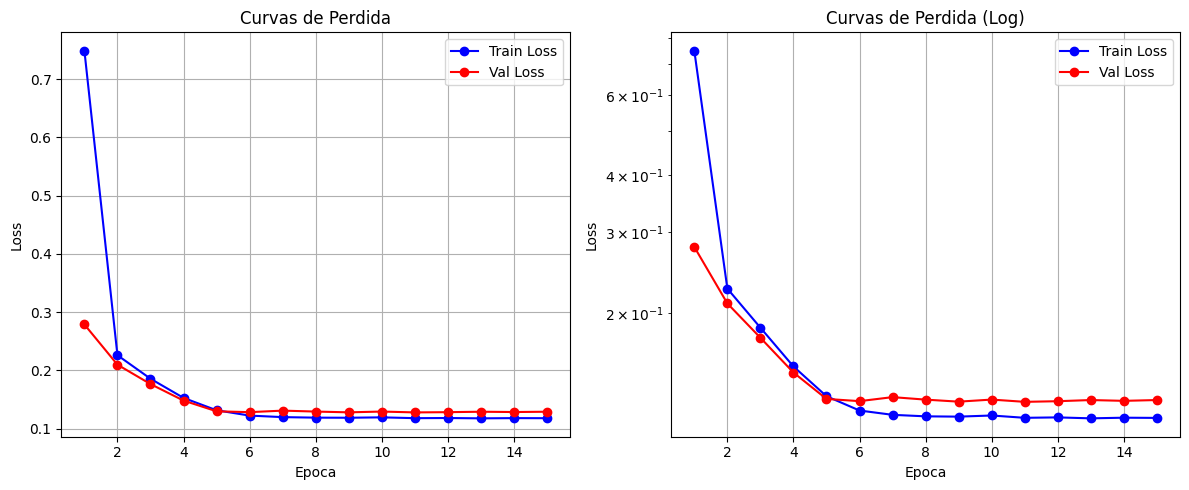

In [38]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, 'b-o', label='Train Loss')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, 'r-o', label='Val Loss')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.title('Curvas de Perdida')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, 'b-o', label='Train Loss')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, 'r-o', label='Val Loss')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.title('Curvas de Perdida (Log)')
plt.legend()
plt.yscale('log')
plt.grid(True)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluación Final en el Conjunto de Test

En la evaluación final sobre el conjunto de test el modelo se comporta muy bien, y además la evaluación fue rápida (unos 5.8 segundos para 30 imágenes), lo que confirma que la inferencia es eficiente una vez entrenado. Para interpretar los resultados, nos fijamos por separado en lo que hace con cajas (detección) y con máscaras (segmentación), usando un umbral de IoU = 0.5.

En bounding boxes los resultados son prácticamente perfectos: tenemos recall = 1.0 (no se nos escapa ningún implante en test) y una precisión del 96.77%, lo que implica muy pocos falsos positivos. Esto se ve también en el recuento TP/FP/FN = 30/1/0: detectamos correctamente 30 casos, solo cometemos 1 falso positivo y no tenemos falsos negativos. Además, el AP@0.5 = 1.0 refuerza la idea de que, a un nivel “estándar” de solape, el modelo localiza muy bien el implante. El Mean IoU de cajas (0.8548) también es alto, lo que sugiere que no solo detecta “algo” cerca, sino que la caja cae bastante ajustada.

En máscaras, los resultados siguen siendo muy buenos, aunque un poco más bajos. Aquí obtenemos precisión = 93.55%, recall = 96.67% y un F1 = 0.9508, con TP/FP/FN = 29/2/1. En una imagen el modelo no llega a segmentar correctamente (un falso negativo), y en dos casos genera máscaras extra (falsos positivos). Aun así, el Mean IoU de máscaras (0.9393) es especialmente alto, lo que indica que cuando segmenta, lo hace de forma bastante precisa y bien alineada con la región real del implante.

Cuando miramos las métricas como IoU bajos/medios el modelo rinde excelente, pero a partir de umbrales altos (por ejemplo 0.85, 0.90, 0.95) el Box AP cae mucho. En cambio, que el AP@0.5 sea 1.0 y que incluso a 0.75 sea 0.8496, nos indica que el modelo es muy sólido para un uso práctico.


In [39]:
checkpoint = torch.load(SAVE_DIR / 'best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Mejor modelo cargado (epoca {checkpoint['epoch'] + 1}, val_loss: {checkpoint['val_loss']:.4f})")

Mejor modelo cargado (epoca 11, val_loss: 0.1278)


In [40]:
from collections import defaultdict
import pandas as pd

def calculate_iou_box(box1, box2):
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])
    
    inter_area = max(0, x2_inter - x1_inter) * max(0, y2_inter - y1_inter)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area if union_area > 0 else 0.0

def calculate_iou_mask(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

def evaluate_model(model, dataset, device, iou_threshold=0.5, conf_threshold=0.5):
    model.eval()
    
    tp_boxes, fp_boxes, fn_boxes = 0, 0, 0
    tp_masks, fp_masks, fn_masks = 0, 0, 0
    iou_boxes, iou_masks = [], []
    all_scores, all_matches = [], []
    
    with torch.no_grad():
        for idx in range(len(dataset)):
            if (idx + 1) % 5 == 0:
                print(f"  Procesando {idx + 1}/{len(dataset)}...")
            
            img, target = dataset[idx]
            if len(target['boxes']) == 0:
                continue
            
            prediction = model([img.to(device)])[0]
            gt_boxes = target['boxes'].cpu().numpy()
            gt_masks = target['masks'].cpu().numpy()
            
            valid_preds = prediction['scores'] > conf_threshold
            pred_boxes = prediction['boxes'][valid_preds].cpu().numpy()
            pred_masks = prediction['masks'][valid_preds, 0].cpu().numpy()
            pred_scores = prediction['scores'][valid_preds].cpu().numpy()
            
            matched_gt_boxes = set()
            for i, pred_box in enumerate(pred_boxes):
                best_iou, best_gt_idx = 0, -1
                for j, gt_box in enumerate(gt_boxes):
                    if j not in matched_gt_boxes:
                        iou = calculate_iou_box(pred_box, gt_box)
                        if iou > best_iou:
                            best_iou, best_gt_idx = iou, j
                
                all_scores.append(pred_scores[i])
                if best_iou >= iou_threshold:
                    tp_boxes += 1
                    matched_gt_boxes.add(best_gt_idx)
                    iou_boxes.append(best_iou)
                    all_matches.append(1)
                else:
                    fp_boxes += 1
                    all_matches.append(0)
            
            fn_boxes += len(gt_boxes) - len(matched_gt_boxes)
            
            matched_gt_masks = set()
            for i, pred_mask in enumerate(pred_masks):
                pred_mask_binary = (pred_mask > 0.5).astype(np.uint8)
                best_iou, best_gt_idx = 0, -1
                for j, gt_mask in enumerate(gt_masks):
                    if j not in matched_gt_masks:
                        iou = calculate_iou_mask(pred_mask_binary, gt_mask)
                        if iou > best_iou:
                            best_iou, best_gt_idx = iou, j
                
                if best_iou >= iou_threshold:
                    tp_masks += 1
                    matched_gt_masks.add(best_gt_idx)
                    iou_masks.append(best_iou)
                else:
                    fp_masks += 1
            
            fn_masks += len(gt_masks) - len(matched_gt_masks)
    
    precision_box = tp_boxes / (tp_boxes + fp_boxes) if (tp_boxes + fp_boxes) > 0 else 0
    recall_box = tp_boxes / (tp_boxes + fn_boxes) if (tp_boxes + fn_boxes) > 0 else 0
    f1_box = 2 * precision_box * recall_box / (precision_box + recall_box) if (precision_box + recall_box) > 0 else 0
    
    precision_mask = tp_masks / (tp_masks + fp_masks) if (tp_masks + fp_masks) > 0 else 0
    recall_mask = tp_masks / (tp_masks + fn_masks) if (tp_masks + fn_masks) > 0 else 0
    f1_mask = 2 * precision_mask * recall_mask / (precision_mask + recall_mask) if (precision_mask + recall_mask) > 0 else 0
    
    if len(all_scores) > 0:
        sorted_indices = np.argsort(all_scores)[::-1]
        sorted_matches = np.array(all_matches)[sorted_indices]
        precisions, recalls, tp_cumsum = [], [], 0
        
        for i in range(len(sorted_matches)):
            tp_cumsum += sorted_matches[i]
            precisions.append(tp_cumsum / (i + 1))
            recalls.append(tp_cumsum / (tp_boxes + fn_boxes))
        
        ap = sum(max([p for r, p in zip(recalls, precisions) if r >= t] or [0]) for t in np.arange(0, 1.1, 0.1)) / 11
    else:
        ap = 0
    
    return {
        'box': {
            'precision': precision_box, 'recall': recall_box, 'f1_score': f1_box,
            'mean_iou': np.mean(iou_boxes) if iou_boxes else 0, 'ap': ap,
            'tp': tp_boxes, 'fp': fp_boxes, 'fn': fn_boxes
        },
        'mask': {
            'precision': precision_mask, 'recall': recall_mask, 'f1_score': f1_mask,
            'mean_iou': np.mean(iou_masks) if iou_masks else 0,
            'tp': tp_masks, 'fp': fp_masks, 'fn': fn_masks
        }
    }

In [41]:
import time
start_time = time.time()

test_metrics = evaluate_model(model, test_dataset, device, iou_threshold=0.5, conf_threshold=0.5)

print(f"\nEvaluacion completada en {time.time() - start_time:.1f}s\n")
print("METRICAS EN TEST SET (IoU threshold = 0.5)")
print("-" * 60)
print("\nBounding Boxes:")
print(f"  Precision: {test_metrics['box']['precision']:.4f} ({test_metrics['box']['precision']*100:.2f}%)")
print(f"  Recall: {test_metrics['box']['recall']:.4f} ({test_metrics['box']['recall']*100:.2f}%)")
print(f"  F1-Score: {test_metrics['box']['f1_score']:.4f}")
print(f"  Mean IoU: {test_metrics['box']['mean_iou']:.4f}")
print(f"  AP@0.5: {test_metrics['box']['ap']:.4f} ({test_metrics['box']['ap']*100:.2f}%)")
print(f"  TP/FP/FN: {test_metrics['box']['tp']}/{test_metrics['box']['fp']}/{test_metrics['box']['fn']}")

print("\nMascaras:")
print(f"  Precision: {test_metrics['mask']['precision']:.4f} ({test_metrics['mask']['precision']*100:.2f}%)")
print(f"  Recall: {test_metrics['mask']['recall']:.4f} ({test_metrics['mask']['recall']*100:.2f}%)")
print(f"  F1-Score: {test_metrics['mask']['f1_score']:.4f}")
print(f"  Mean IoU: {test_metrics['mask']['mean_iou']:.4f}")
print(f"  TP/FP/FN: {test_metrics['mask']['tp']}/{test_metrics['mask']['fp']}/{test_metrics['mask']['fn']}")

  Procesando 5/30...
  Procesando 10/30...
  Procesando 15/30...
  Procesando 20/30...
  Procesando 25/30...
  Procesando 30/30...

Evaluacion completada en 5.8s

METRICAS EN TEST SET (IoU threshold = 0.5)
------------------------------------------------------------

Bounding Boxes:
  Precision: 0.9677 (96.77%)
  Recall: 1.0000 (100.00%)
  F1-Score: 0.9836
  Mean IoU: 0.8548
  AP@0.5: 1.0000 (100.00%)
  TP/FP/FN: 30/1/0

Mascaras:
  Precision: 0.9355 (93.55%)
  Recall: 0.9667 (96.67%)
  F1-Score: 0.9508
  Mean IoU: 0.9393
  TP/FP/FN: 29/2/1


In [42]:
print("\nCalculando mAP...")

iou_thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
ap_values_box = []
ap_values_mask_precision = []

for iou_thresh in iou_thresholds:
    metrics = evaluate_model(model, test_dataset, device, iou_threshold=iou_thresh, conf_threshold=0.5)
    ap_values_box.append(metrics['box']['ap'])
    ap_values_mask_precision.append(metrics['mask']['precision'])
    print(f"  IoU@{iou_thresh:.2f} - Box AP: {metrics['box']['ap']:.4f}, Mask Precision: {metrics['mask']['precision']:.4f}")

mAP_box = np.mean(ap_values_box)
mAP_mask_precision_avg = np.mean(ap_values_mask_precision)

print("\n" + "="*60)
print("METRICAS COCO-STYLE")
print("="*60)
print(f"mAP@[0.5:0.95] (Boxes): {mAP_box:.4f} ({mAP_box*100:.2f}%)")
print(f"AP@0.5 (Boxes): {ap_values_box[0]:.4f} ({ap_values_box[0]*100:.2f}%)")
print(f"AP@0.75 (Boxes): {ap_values_box[5]:.4f} ({ap_values_box[5]*100:.2f}%)")
print(f"Mean Precision (Masks): {mAP_mask_precision_avg:.4f} ({mAP_mask_precision_avg*100:.2f}%)")

metrics_summary = {
    'test_metrics_iou_0.5': test_metrics,
    'mAP_box_0.5_0.95': float(mAP_box),
    'AP_box_0.5': float(ap_values_box[0]),
    'AP_box_0.75': float(ap_values_box[5]),
    'iou_thresholds': iou_thresholds,
    'ap_values_box': [float(v) for v in ap_values_box],
    'ap_values_mask_precision': [float(v) for v in ap_values_mask_precision]
}

with open(SAVE_DIR / 'test_metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2, default=lambda x: float(x) if isinstance(x, np.floating) else x)

print(f"\nMetricas guardadas en {SAVE_DIR / 'test_metrics.json'}")


Calculando mAP...
  Procesando 5/30...
  Procesando 10/30...
  Procesando 15/30...
  Procesando 20/30...
  Procesando 25/30...
  Procesando 30/30...
  IoU@0.50 - Box AP: 1.0000, Mask Precision: 0.9355
  Procesando 5/30...
  Procesando 10/30...
  Procesando 15/30...
  Procesando 20/30...
  Procesando 25/30...
  Procesando 30/30...
  IoU@0.55 - Box AP: 1.0000, Mask Precision: 0.9355
  Procesando 5/30...
  Procesando 10/30...
  Procesando 15/30...
  Procesando 20/30...
  Procesando 25/30...
  Procesando 30/30...
  IoU@0.60 - Box AP: 1.0000, Mask Precision: 0.9355
  Procesando 5/30...
  Procesando 10/30...
  Procesando 15/30...
  Procesando 20/30...
  Procesando 25/30...
  Procesando 30/30...
  IoU@0.65 - Box AP: 1.0000, Mask Precision: 0.9355
  Procesando 5/30...
  Procesando 10/30...
  Procesando 15/30...
  Procesando 20/30...
  Procesando 25/30...
  Procesando 30/30...
  IoU@0.70 - Box AP: 0.8939, Mask Precision: 0.9355
  Procesando 5/30...
  Procesando 10/30...
  Procesando 15/30...
 

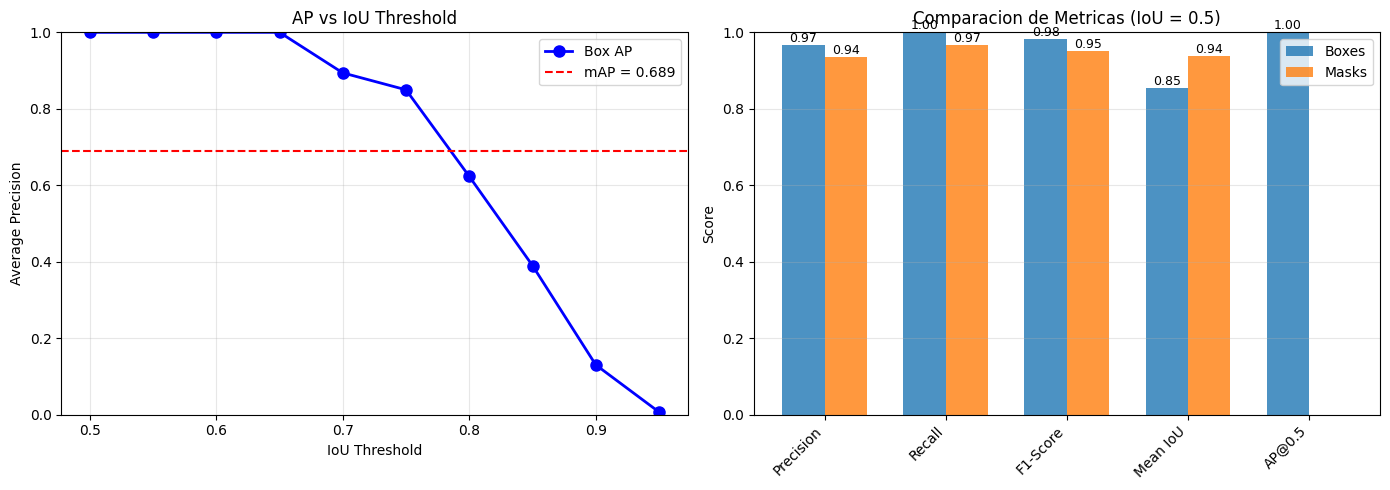

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(iou_thresholds, ap_values_box, 'b-o', linewidth=2, markersize=8, label='Box AP')
axes[0].axhline(y=mAP_box, color='r', linestyle='--', label=f'mAP = {mAP_box:.3f}')
axes[0].set_xlabel('IoU Threshold')
axes[0].set_ylabel('Average Precision')
axes[0].set_title('AP vs IoU Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

metrics_names = ['Precision', 'Recall', 'F1-Score', 'Mean IoU', 'AP@0.5']
box_values = [test_metrics['box']['precision'], test_metrics['box']['recall'], 
              test_metrics['box']['f1_score'], test_metrics['box']['mean_iou'], 
              test_metrics['box']['ap']]
mask_values = [test_metrics['mask']['precision'], test_metrics['mask']['recall'], 
               test_metrics['mask']['f1_score'], test_metrics['mask']['mean_iou'], 0]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[1].bar(x - width/2, box_values, width, label='Boxes', alpha=0.8)
bars2 = axes[1].bar(x + width/2, mask_values, width, label='Masks', alpha=0.8)

axes[1].set_ylabel('Score')
axes[1].set_title('Comparacion de Metricas (IoU = 0.5)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_names, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([0, 1])

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[1].text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}',
                        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.1 Visualización de Predicciones en el Conjunto de Test


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6555357..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6555357..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6555357..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6555357..1.3418957].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6212862..1.7685405].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6212862..1.7685405].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.621286

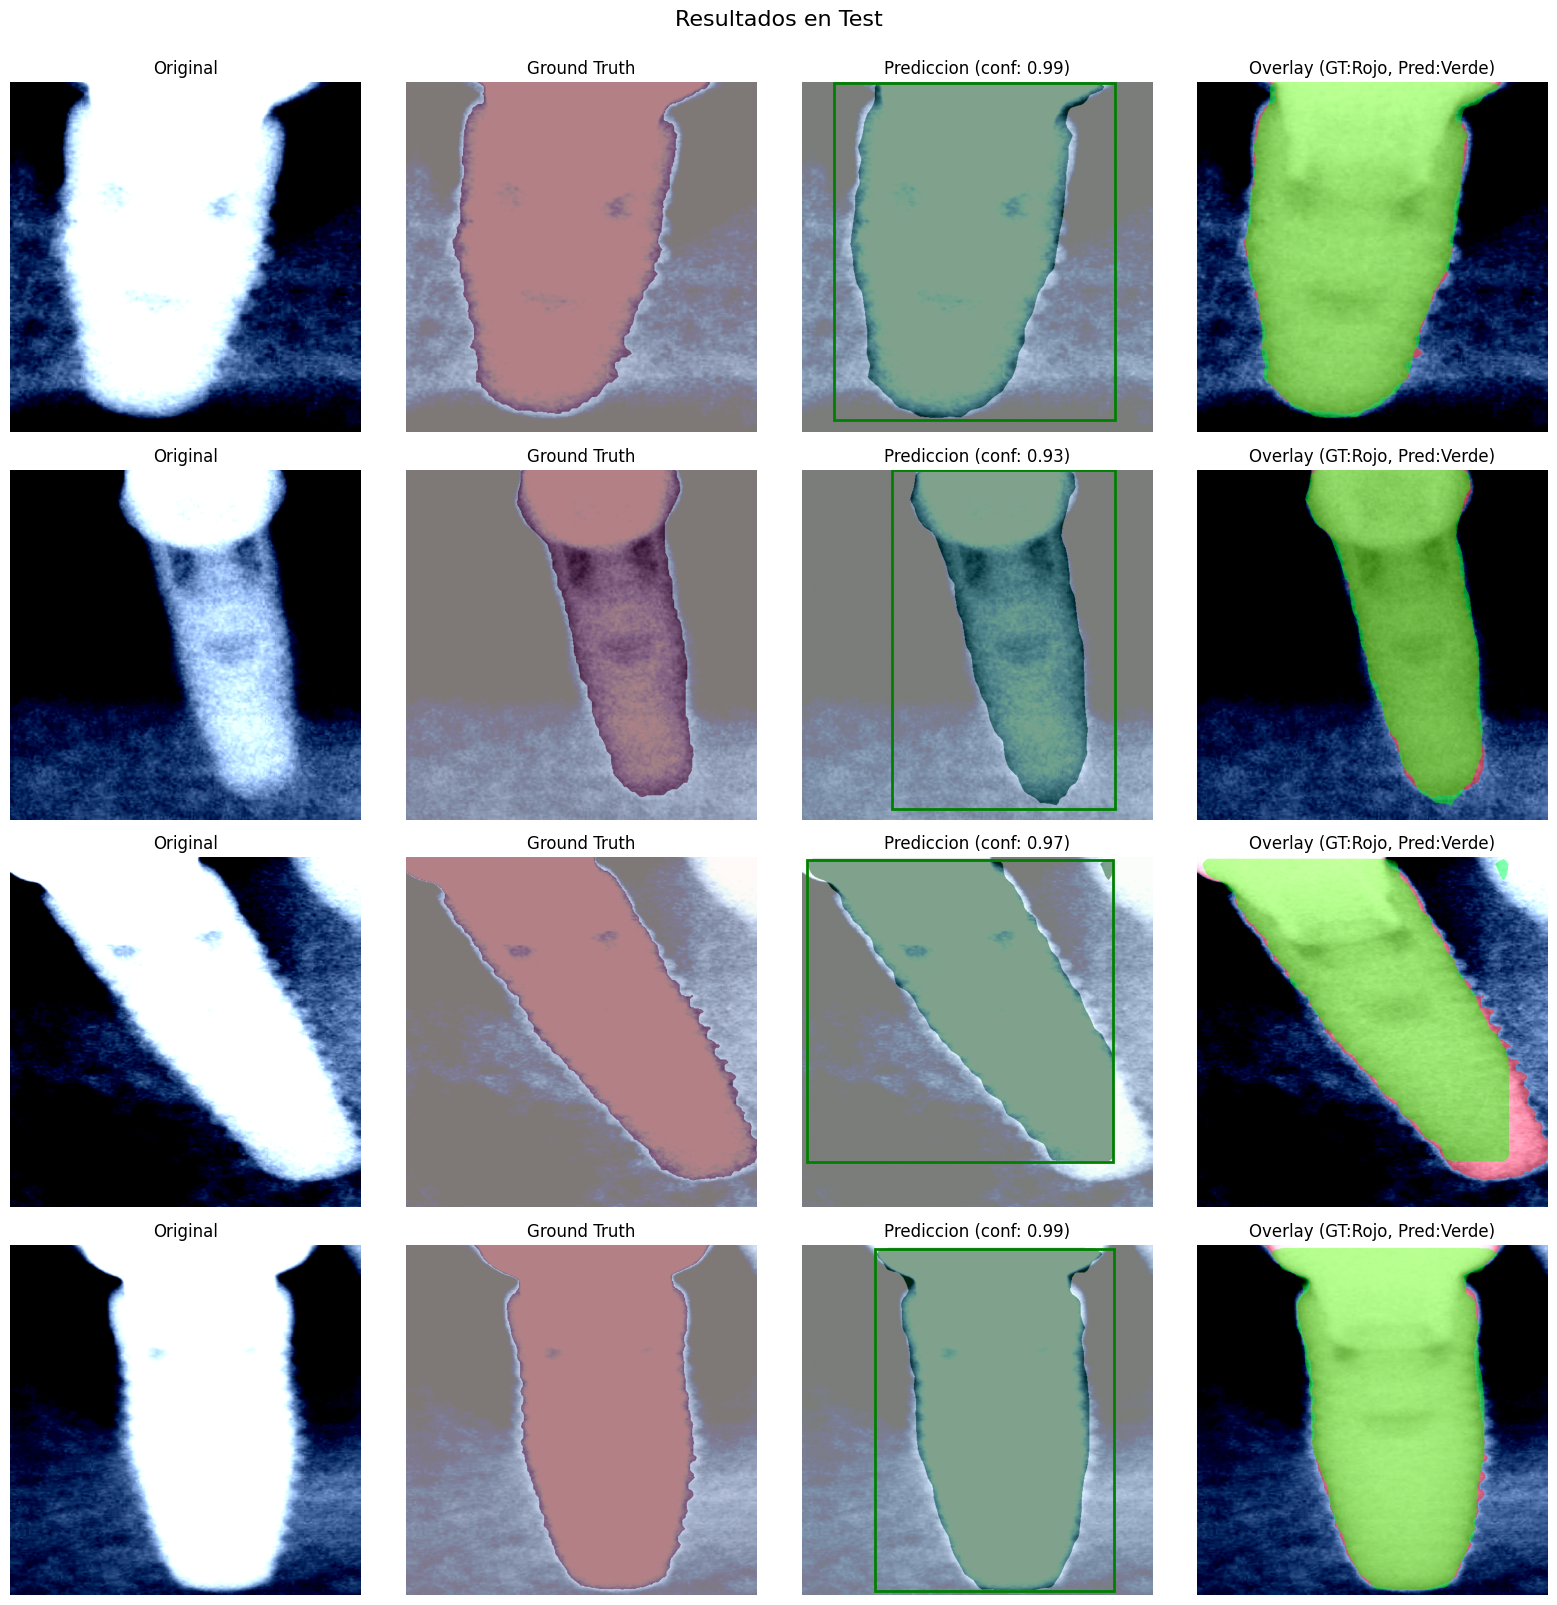

In [44]:
def visualize_predictions(model, dataset, device, num_samples=4, threshold=0.5):
    model.eval()
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples*4))
    if num_samples == 1:
        axes = [axes]
    
    with torch.no_grad():
        for idx, sample_idx in enumerate(indices):
            img, target = dataset[sample_idx]
            prediction = model([img.to(device)])[0]
            
            img_np = img.permute(1, 2, 0).cpu().numpy()
            gt_mask = target['masks'][0].cpu().numpy() if len(target['masks']) > 0 else np.zeros_like(img_np[:,:,0])
            
            if len(prediction['masks']) > 0 and prediction['scores'][0] > threshold:
                pred_mask = (prediction['masks'][0, 0].cpu().numpy() > 0.5).astype(np.uint8)
                pred_score = prediction['scores'][0].cpu().item()
                pred_box = prediction['boxes'][0].cpu().numpy()
            else:
                pred_mask = np.zeros_like(img_np[:,:,0])
                pred_score = 0.0
                pred_box = None
            
            axes[idx][0].imshow(img_np)
            axes[idx][0].set_title('Original')
            axes[idx][0].axis('off')
            
            axes[idx][1].imshow(img_np)
            axes[idx][1].imshow(gt_mask, alpha=0.5, cmap='Reds')
            axes[idx][1].set_title('Ground Truth')
            axes[idx][1].axis('off')
            
            axes[idx][2].imshow(img_np)
            axes[idx][2].imshow(pred_mask, alpha=0.5, cmap='Greens')
            if pred_box is not None:
                rect = plt.Rectangle((pred_box[0], pred_box[1]), pred_box[2] - pred_box[0], 
                                    pred_box[3] - pred_box[1], fill=False, color='green', linewidth=2)
                axes[idx][2].add_patch(rect)
            axes[idx][2].set_title(f'Prediccion (conf: {pred_score:.2f})')
            axes[idx][2].axis('off')
            
            overlay = img_np.copy()
            overlay[gt_mask > 0.5] = overlay[gt_mask > 0.5] * 0.5 + np.array([1, 0, 0]) * 0.5
            overlay[pred_mask > 0.5] = overlay[pred_mask > 0.5] * 0.5 + np.array([0, 1, 0]) * 0.5
            axes[idx][3].imshow(overlay)
            axes[idx][3].set_title('Overlay (GT:Rojo, Pred:Verde)')
            axes[idx][3].axis('off')
    
    plt.suptitle('Resultados en Test', fontsize=16, y=1.00)
    plt.tight_layout()
    plt.savefig(SAVE_DIR / 'test_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(model, test_dataset, device, num_samples=4, threshold=0.5)

Aqui mostramos el codigo del gridsearch que intentamos ejecutar para encontrar los mejores hiperparámetros. Como mencionamos antes esto era bastante costoso y decidimos que no era necesario (mejorar)

In [ ]:
# from itertools import product

# maskrcnn_param_grid = {
#     'lr': [0.001, 0.005],
#     'batch_size': [2, 4],
#     'optimizer_type': ['SGD'],
#     'lr_scheduler_step': [3, 5],
#     'lr_scheduler_gamma': [0.1],
#     'epochs': [15],
#     'weight_decay': [0.0005]
# }

# # Generar todas las combinaciones
# maskrcnn_param_names = list(maskrcnn_param_grid.keys())
# maskrcnn_all_combinations = [
#     dict(zip(maskrcnn_param_names, values))
#     for values in product(*maskrcnn_param_grid.values())
# ]

# print(f"Total combinaciones Mask R-CNN: {len(maskrcnn_all_combinations)}")
# print("\nCombinaciones:")
# for idx, config in enumerate(maskrcnn_all_combinations):
#     print(f"Exp {idx:02d}: LR={config['lr']}, Batch={config['batch_size']}, "
#           f"Opt={config['optimizer_type']}, Step={config['lr_scheduler_step']}, "
#           f"Gamma={config['lr_scheduler_gamma']}")
# ### 4.2. Funciones de Entrenamiento y Evaluación para Grid Search
# def train_maskrcnn_experiment(config, train_dataset, val_dataset, device, exp_name):
#     """
#     Entrena Mask R-CNN con una configuración específica
#     """
#     print(f"\n{'='*80}")
#     print(f"Iniciando experimento: {exp_name}")
#     print(f"Configuración: {config}")
#     print(f"{'='*80}\n")
    
#     # Crear DataLoaders con el batch_size especificado
#     def collate_fn(batch):
#         return tuple(zip(*batch))
    
#     train_loader = torch.utils.data.DataLoader(
#         train_dataset, 
#         batch_size=config['batch_size'], 
#         shuffle=True, 
#         num_workers=0, 
#         collate_fn=collate_fn
#     )
#     val_loader = torch.utils.data.DataLoader(
#         val_dataset, 
#         batch_size=config['batch_size'], 
#         shuffle=False, 
#         num_workers=0, 
#         collate_fn=collate_fn
#     )
    
#     # Crear modelo
#     model = get_model_instance_segmentation(num_classes=2)
#     model.to(device)
    
#     # Configurar optimizador
#     params = [p for p in model.parameters() if p.requires_grad]
#     if config['optimizer_type'] == 'SGD':
#         optimizer = torch.optim.SGD(
#             params, 
#             lr=config['lr'], 
#             momentum=0.9, 
#             weight_decay=config['weight_decay']
#         )
#     elif config['optimizer_type'] == 'Adam':
#         optimizer = torch.optim.Adam(
#             params, 
#             lr=config['lr'], 
#             weight_decay=config['weight_decay']
#         )
#     else:
#         raise ValueError(f"Optimizador desconocido: {config['optimizer_type']}")
    
#     # Configurar learning rate scheduler
#     lr_scheduler = torch.optim.lr_scheduler.StepLR(
#         optimizer, 
#         step_size=config['lr_scheduler_step'], 
#         gamma=config['lr_scheduler_gamma']
#     )
    
#     # Entrenamiento
#     train_losses = []
#     val_losses = []
#     best_val_loss = float('inf')
#     start_time = time.time()
    
#     for epoch in range(config['epochs']):
#         # Entrenamiento
#         model.train()
#         epoch_loss = 0
#         valid_batches = 0
        
#         for i, (images, targets) in enumerate(train_loader):
#             valid_indices = [idx for idx, t in enumerate(targets) if len(t['boxes']) > 0]
#             if len(valid_indices) == 0:
#                 continue
            
#             images = [images[idx].to(device) for idx in valid_indices]
#             targets = [{k: v.to(device) for k, v in targets[idx].items()} for idx in valid_indices]
            
#             loss_dict = model(images, targets)
#             losses = sum(loss for loss in loss_dict.values())
            
#             if torch.isnan(losses) or torch.isinf(losses):
#                 continue
            
#             optimizer.zero_grad()
#             losses.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             optimizer.step()
            
#             epoch_loss += losses.item()
#             valid_batches += 1
        
#         train_loss = epoch_loss / valid_batches if valid_batches > 0 else float('nan')
#         train_losses.append(train_loss)
        
#         # Validación
#         model.train()
#         val_loss = 0
#         valid_batches = 0
        
#         with torch.no_grad():
#             for images, targets in val_loader:
#                 valid_indices = [idx for idx, t in enumerate(targets) if len(t['boxes']) > 0]
#                 if len(valid_indices) == 0:
#                     continue
                
#                 images = [images[idx].to(device) for idx in valid_indices]
#                 targets = [{k: v.to(device) for k, v in targets[idx].items()} for idx in valid_indices]
                
#                 loss_dict = model(images, targets)
#                 losses = sum(loss for loss in loss_dict.values())
                
#                 if not (torch.isnan(losses) or torch.isinf(losses)):
#                     val_loss += losses.item()
#                     valid_batches += 1
        
#         val_loss = val_loss / valid_batches if valid_batches > 0 else float('nan')
#         val_losses.append(val_loss)
        
#         # Actualizar scheduler
#         lr_scheduler.step()
        
#         # Guardar mejor modelo
#         if not np.isnan(val_loss) and val_loss < best_val_loss:
#             best_val_loss = val_loss
        
#         if (epoch + 1) % 5 == 0 or epoch == 0:
#             print(f"Época {epoch+1}/{config['epochs']}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, LR={optimizer.param_groups[0]['lr']:.6f}")
    
#     training_time = time.time() - start_time
    
#     print(f"\n{exp_name} completado:")
#     return {
#         'model': model,
#         'train_losses': train_losses,
#         'val_losses': val_losses,
#         'best_val_loss': best_val_loss,
#         'training_time': training_time,
#         'config': config
#     }
# maskrcnn_results = {}

# print(f"{'='*80}")
# print(f"INICIANDO GRID SEARCH PARA MASK R-CNN")
# print(f"Total de experimentos: {len(maskrcnn_all_combinations)}")
# print(f"{'='*80}\n")

# for idx, config in enumerate(maskrcnn_all_combinations):
#     exp_name = f"maskrcnn_exp_{idx:02d}"
    
#     try:
#         result = train_maskrcnn_experiment(
#             config=config,
#             train_dataset=train_dataset,
#             val_dataset=val_dataset,
#             device=device,
#             exp_name=exp_name
#         )
        
#         maskrcnn_results[exp_name] = result
        
#         # Guardar modelo (opcional, puede ocupar mucho espacio)
#         # torch.save(result['model'].state_dict(), SAVE_DIR / f'{exp_name}_model.pth')
        
#     except Exception as e:
#     except Exception as e:
#         maskrcnn_results[exp_name] = {
#             'error': str(e),
#             'config': config
#         }
#         continue

# print(f"\n{'='*80}")
# print("GRID SEARCH MASK R-CNN COMPLETADO")
# print(f"{'='*80}")
# # Crear DataFrame con resultados
# maskrcnn_results_data = []

# for exp_name, result in maskrcnn_results.items():
#     if 'error' in result:
#         print(f" {exp_name} falló: {result['error']}")
#         continue
    
#     maskrcnn_results_data.append({
#         'Experimento': exp_name,
#         'LR': result['config']['lr'],
#         'Batch Size': result['config']['batch_size'],
#         'Optimizer': result['config']['optimizer_type'],
#         'LR Step': result['config']['lr_scheduler_step'],
#         'LR Gamma': result['config']['lr_scheduler_gamma'],
#         'Épocas': result['config']['epochs'],
#         'Best Val Loss': result['best_val_loss'],
#         'Final Train Loss': result['train_losses'][-1] if result['train_losses'] else float('nan'),
#         'Final Val Loss': result['val_losses'][-1] if result['val_losses'] else float('nan'),
#         'Tiempo (min)': result['training_time'] / 60
#     })

# maskrcnn_df_results = pd.DataFrame(maskrcnn_results_data)
# maskrcnn_df_results = maskrcnn_df_results.sort_values('Best Val Loss', ascending=True)

# print("\n" + "="*120)
# print("RESULTADOS DEL GRID SEARCH - MASK R-CNN")
# print("="*120)
# print(maskrcnn_df_results.to_string(index=False))
# print("\n")

# if len(maskrcnn_df_results) > 0:
#     best_maskrcnn_exp = maskrcnn_df_results.iloc[0]['Experimento']
#     best_maskrcnn_val_loss = maskrcnn_df_results.iloc[0]['Best Val Loss']
    
#     print(f"MEJOR MODELO: {best_maskrcnn_exp}")
#     print(f"Mejor Val Loss: {best_maskrcnn_val_loss:.4f}")
#     print(f"Configuración: {maskrcnn_results[best_maskrcnn_exp]['config']}")
#     print(f"Tiempo de entrenamiento: {maskrcnn_results[best_maskrcnn_exp]['training_time']/60:.2f} minutos")
# else:
#     print(" No hay resultados válidos para mostrar")
# fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# # 1. Mejor Val Loss por experimento
# axes[0, 0].barh(maskrcnn_df_results['Experimento'], maskrcnn_df_results['Best Val Loss'], color='teal')
# axes[0, 0].set_xlabel('Best Validation Loss')
# axes[0, 0].set_title('Mejor Loss de Validación por Experimento')
# axes[0, 0].grid(axis='x', alpha=0.3)
# axes[0, 0].invert_yaxis()

# # 2. Tiempo vs Precisión (Val Loss)
# colors = ['red' if opt == 'SGD' else 'blue' for opt in maskrcnn_df_results['Optimizer']]
# scatter = axes[0, 1].scatter(
#     maskrcnn_df_results['Tiempo (min)'], 
#     maskrcnn_df_results['Best Val Loss'], 
#     s=200, 
#     alpha=0.6, 
#     c=colors
# )
# for idx, row in maskrcnn_df_results.iterrows():
#     axes[0, 1].annotate(
#         row['Experimento'].replace('maskrcnn_exp_', ''), 
#         (row['Tiempo (min)'], row['Best Val Loss']),
#         fontsize=9, 
#         alpha=0.8, 
#         ha='center'
#     )
# axes[0, 1].set_xlabel('Tiempo de entrenamiento (min)')
# axes[0, 1].set_ylabel('Best Validation Loss')
# axes[0, 1].set_title('Eficiencia: Tiempo vs Val Loss (Rojo=SGD, Azul=Adam)')
# axes[0, 1].grid(alpha=0.3)
# axes[0, 1].invert_yaxis()

# # 3. Comparación de hiperparámetros
# x = np.arange(len(maskrcnn_df_results))
# width = 0.25
# # 3. Comparación de hiperparámetros
# bars1 = axes[1, 0].bar(x - width, maskrcnn_df_results['LR']*100, width, label='LR (x100)', alpha=0.8)
# bars2 = axes[1, 0].bar(x, maskrcnn_df_results['Batch Size'], width, label='Batch Size', alpha=0.8)
# bars3 = axes[1, 0].bar(x + width, maskrcnn_df_results['LR Step'], width, label='LR Scheduler Step', alpha=0.8)
# bars1 = axes[1, 0].bar(x - width, maskrcnn_df_results['LR']*100, width, label='LR (x100)', alpha=0.8)
# axes[1, 0].set_xlabel('Experimento')
# axes[1, 0].set_ylabel('Valor')
# axes[1, 0].set_title('Comparación de Hiperparámetros')
# axes[1, 0].set_xticks(x)
# axes[1, 0].set_xticklabels([exp.replace('maskrcnn_exp_', '') for exp in maskrcnn_df_results['Experimento']], rotation=45)
# axes[1, 0].legend()
# axes[1, 0].grid(axis='y', alpha=0.3)

# # 4. Curvas de entrenamiento del mejor modelo
# if len(maskrcnn_df_results) > 0:
#     best_exp = maskrcnn_df_results.iloc[0]['Experimento']
#     best_result = maskrcnn_results[best_exp]
    
#     epochs_range = range(1, len(best_result['train_losses']) + 1)
#     axes[1, 1].plot(epochs_range, best_result['train_losses'], 'b-o', label='Train Loss', linewidth=2)
#     axes[1, 1].plot(epochs_range, best_result['val_losses'], 'r-o', label='Val Loss', linewidth=2)
#     axes[1, 1].set_xlabel('Época')
#     axes[1, 1].set_ylabel('Loss')
#     axes[1, 1].set_title(f'Curvas de Entrenamiento - Mejor Modelo ({best_exp})')
#     axes[1, 1].legend()
#     axes[1, 1].grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig(SAVE_DIR / 'maskrcnn_grid_search_results.png', dpi=150, bbox_inches='tight')
# plt.show()
# if len(maskrcnn_df_results) > 0:
#     # Obtener el mejor modelo
#     best_maskrcnn_exp = maskrcnn_df_results.iloc[0]['Experimento']
#     best_maskrcnn_model = maskrcnn_results[best_maskrcnn_exp]['model']
    
#     print(f"Evaluando el mejor modelo: {best_maskrcnn_exp}")
#     print(f"Configuración: {maskrcnn_results[best_maskrcnn_exp]['config']}")
#     print("\nEvaluando en conjunto de test...")
#     print(f"Evaluando el mejor modelo: {best_maskrcnn_exp}")
#     # Evaluar en test set
#     start_time = time.time()
#     best_test_metrics = evaluate_model(
#         best_maskrcnn_model, 
#         test_dataset, 
#         device, 
#         iou_threshold=0.5, 
#         conf_threshold=0.5
#     )
#     eval_time = time.time() - start_time
    
#     print(f"\nEvaluación completada en {eval_time:.1f}s\n")
#     print("="*80)
#     print(f"MÉTRICAS EN TEST SET - MEJOR MODELO ({best_maskrcnn_exp})")
#     print("="*80)
#     print("="*80)
#     print(f"MÉTRICAS EN TEST SET - MEJOR MODELO ({best_maskrcnn_exp})")
#     print("="*80)
    
#     print("\n Bounding Boxes:")
#     print(f"  Precision: {best_test_metrics['box']['precision']:.4f} ({best_test_metrics['box']['precision']*100:.2f}%)")
#     print(f"  Recall: {best_test_metrics['box']['recall']:.4f} ({best_test_metrics['box']['recall']*100:.2f}%)")
#     print(f"  F1-Score: {best_test_metrics['box']['f1_score']:.4f}")
#     print(f"  Mean IoU: {best_test_metrics['box']['mean_iou']:.4f}")
#     print(f"  AP@0.5: {best_test_metrics['box']['ap']:.4f} ({best_test_metrics['box']['ap']*100:.2f}%)")
#     print(f"  TP: {best_test_metrics['box']['tp']}, FP: {best_test_metrics['box']['fp']}, FN: {best_test_metrics['box']['fn']}")
    
#     print("\n Máscaras de Segmentación:")
#     print(f"  Precision: {best_test_metrics['mask']['precision']:.4f} ({best_test_metrics['mask']['precision']*100:.2f}%)")
#     print(f"  Recall: {best_test_metrics['mask']['recall']:.4f} ({best_test_metrics['mask']['recall']*100:.2f}%)")
#     print(f"  F1-Score: {best_test_metrics['mask']['f1_score']:.4f}")
#     print(f"  Mean IoU: {best_test_metrics['mask']['mean_iou']:.4f}")
#     print(f"  TP: {best_test_metrics['mask']['tp']}, FP: {best_test_metrics['mask']['fp']}, FN: {best_test_metrics['mask']['fn']}")
    
#     # Guardar el mejor modelo
#     best_model_path = SAVE_DIR / f'{best_maskrcnn_exp}_best.pth'
#     torch.save({
#         'model_state_dict': best_maskrcnn_model.state_dict(),
#         'config': maskrcnn_results[best_maskrcnn_exp]['config'],
#         'test_metrics': best_test_metrics,
#         'val_loss': maskrcnn_results[best_maskrcnn_exp]['best_val_loss']
#     }, best_model_path)
    
#     print(f"\n Mejor modelo guardado en: {best_model_path}")
# else:
#     print(" No hay resultados para evaluar")
# # Crear tabla comparativa
# summary_data = []

# # Datos de YOLO (del mejor modelo)
# if 'best_exp' in locals() and 'yolo_results' in locals():
#     yolo_best = yolo_results[best_exp]
#     summary_data.append({
#         'Modelo': 'YOLO11',
#         'Experimento': best_exp,
#         'mAP@50': yolo_best['map50'],
#         'Precision': yolo_best['precision'],
#         'Recall': yolo_best['recall'],
#         'Tiempo (min)': yolo_best['training_time'] / 60,
#         'Config': f"LR={yolo_best['config']['lr0']}, Freeze={yolo_best['config']['freeze']}, Aug={yolo_best['config']['augment']}"
#     })

# # Datos de Mask R-CNN (del mejor modelo)
# if len(maskrcnn_df_results) > 0:
#     maskrcnn_best = maskrcnn_results[best_maskrcnn_exp]
#     summary_data.append({
#         'Modelo': 'Mask R-CNN',
#         'Experimento': best_maskrcnn_exp,
#         'mAP@50': best_test_metrics['box']['ap'],
#         'Precision': best_test_metrics['box']['precision'],
#         'Recall': best_test_metrics['box']['recall'],
#         'Tiempo (min)': maskrcnn_best['training_time'] / 60,
#         'Config': f"LR={maskrcnn_best['config']['lr']}, Opt={maskrcnn_best['config']['optimizer_type']}, Batch={maskrcnn_best['config']['batch_size']}"
#     })

# if len(summary_data) > 0:
#     summary_df = pd.DataFrame(summary_data)
    
#     print("\n" + "="*120)
#     print("COMPARACIÓN FINAL: MEJOR YOLO11 vs MEJOR MASK R-CNN")
#     print("="*120)
#     print(summary_df.to_string(index=False))
#     print("\n")
    
#     # Visualización comparativa
#     fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
#     # Comparación de métricas
#     metrics_names = ['mAP@50', 'Precision', 'Recall']
#     x = np.arange(len(metrics_names))
#     width = 0.35
    
#     if len(summary_df) == 2:
#         yolo_metrics = [summary_df.iloc[0]['mAP@50'], summary_df.iloc[0]['Precision'], summary_df.iloc[0]['Recall']]
#         maskrcnn_metrics = [summary_df.iloc[1]['mAP@50'], summary_df.iloc[1]['Precision'], summary_df.iloc[1]['Recall']]
        
#         axes[0].bar(x - width/2, yolo_metrics, width, label='YOLO11', alpha=0.8, color='steelblue')
#         axes[0].bar(x + width/2, maskrcnn_metrics, width, label='Mask R-CNN', alpha=0.8, color='teal')
#         axes[0].set_ylabel('Valor')
#         axes[0].set_title('Comparación de Métricas de Detección')
#         axes[0].set_xticks(x)
#         axes[0].set_xticklabels(metrics_names)
#         axes[0].legend()
#         axes[0].grid(axis='y', alpha=0.3)
        
#         # Tiempo de entrenamiento
#         models = ['YOLO11', 'Mask R-CNN']
#         times = [summary_df.iloc[0]['Tiempo (min)'], summary_df.iloc[1]['Tiempo (min)']]
#         axes[1].bar(models, times, alpha=0.8, color=['steelblue', 'teal'])
#         axes[1].set_ylabel('Tiempo (minutos)')
#         axes[1].set_title('Tiempo de Entrenamiento')
#         axes[1].grid(axis='y', alpha=0.3)
        
#         yolo_score = (yolo_metrics[0] + yolo_metrics[1] + yolo_metrics[2]) / 3
#         maskrcnn_score = (maskrcnn_metrics[0] + maskrcnn_metrics[1] + maskrcnn_metrics[2]) / 3
        
#         axes[2].bar(models, [yolo_score, maskrcnn_score], alpha=0.8, color=['steelblue', 'teal'])
#         axes[2].set_ylabel('Score Promedio')
#         axes[2].set_title('Performance Global (Promedio de Métricas)')
#         axes[2].set_ylim([0, 1])
#         axes[2].grid(axis='y', alpha=0.3)
        
#         for i, (model, score) in enumerate(zip(models, [yolo_score, maskrcnn_score])):
#             axes[2].text(i, score + 0.02, f'{score:.3f}', ha='center', fontweight='bold')
    
#     plt.tight_layout()
#     plt.savefig(SAVE_DIR / 'yolo_vs_maskrcnn_comparison.png', dpi=150, bbox_inches='tight')
#     plt.show()
    
#     print("\n" + "="*120)
#     print("CONCLUSIONES:")
#     print("="*120)
#     if len(summary_df) == 2:
#         winner = 'YOLO11' if yolo_score > maskrcnn_score else 'Mask R-CNN'
#         print(f"🏆 Mejor modelo general: {winner}")
#         print(f"   - YOLO11 Score: {yolo_score:.4f}")
#         print(f"   - Mask R-CNN Score: {maskrcnn_score:.4f}")
#         print(f"\n💡 Ventajas de YOLO11: Más rápido y eficiente")
#         print(f"💡 Ventajas de Mask R-CNN: Segmentación de instancias y mayor precisión en localización")